# Case Study 1 — ERP Correlates of Neuropsychological Performance

This notebook implements the analysis described in Section 4.2 of the
companion paper. The research question is:

> **Are the amplitude and latency of specific ERP components (N400, P300)
> associated with neuropsychological performance in post-stroke patients?**

Two well-characterised ERP components are used:
- **N400** — a negative deflection ~400 ms post-stimulus, indexing semantic
  processing (Kutas & Federmeier, 2011)
- **P300** — a positive deflection ~300 ms post-target, indexing attentional
  resource allocation (Polich, 2007)

From each component we extract **amplitude** (mean µV within a predefined
time window) and **latency** (ms of peak amplitude), yielding four
participant-level neural predictors.

## Pipeline

1. **Data Wrangling** — load, inspect, check ranges, missing data, distributions,
   outliers, multicollinearity
2. **Analysis** — descriptive stats, bivariate correlations, multiple regression,
   diagnostics, multiple comparison correction
3. **Export** — save tables and figures

> All code is defined directly in this notebook for transparency and
> reproducibility. Each step is explained as we go.


## 0. Setup

Import the libraries we will use throughout the analysis.

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, shapiro, zscore
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multitest import multipletests
from statsmodels.tools.tools import add_constant

sns.set_style("whitegrid")
print("All imports successful.")


All imports successful.


### Output directories

In [70]:
OUTPUTS = "CaseStudy_1/outputs"
FIGS    = f"{OUTPUTS}/figures"
REPORTS = f"{OUTPUTS}/report"
RESULTS = f"{OUTPUTS}/results"


### Load datasets

The datasets are stored as separate CSV files linked by `subject_id`.

In [71]:
npsy = pd.read_csv("../data/dataset_NPSY.csv")
eeg  = pd.read_csv("../data/dataset_P300.csv")
print(f"NPSY: {npsy.shape}  columns: {list(npsy.columns)}")
print(f"EEG:  {eeg.shape}  columns: {list(eeg.columns)}")


NPSY: (40, 9)  columns: ['subject_id', 'age', 'sex', 'education', 'severity', 'criq', 'apacs', 'matrix', 'moca']
EEG:  (40, 5)  columns: ['subject_id', 'n400_amp', 'n400_lat', 'p300_amp', 'p300_lat']


Merge on `subject_id` (inner join keeps only subjects present in both).

In [72]:
df = pd.merge(npsy, eeg, on="subject_id", how="inner")
print(f"Merged: {df.shape[0]} subjects × {df.shape[1]} variables")
df.head()


Merged: 40 subjects × 13 variables


,subject_id,age,sex,education,severity,criq,apacs,matrix,moca,n400_amp,n400_lat,p300_amp,p300_lat
0,sub-001,69,1,13,1.112,90.3,0.7256,37.21,23.85,4.165,404.22,13.143,352.56
1,sub-002,60,0,13,1.456,122.9,0.8220,55.34,27.31,3.828,387.88,18.586,333.19
2,sub-003,72,0,16,3.617,96.2,0.7263,30.78,23.18,3.135,416.21,11.310,420.96
3,sub-004,74,1,18,3.228,114.3,0.7579,30.56,19.44,1.220,500.00,8.035,410.68
4,sub-005,53,1,13,1.719,86.0,0.7874,47.26,24.25,5.160,418.78,13.374,368.91


---
## 1. Data Wrangling

### 1.1 Initial inspection

We check dataset dimensions, column types, and basic descriptive statistics.

**Expected clinical ranges:**

| Variable          | Expected range  |
|-------------------|-----------------|
| Age               | 18–100 years    |
| CRIq              | 70–130          |
| N400 amplitude    | 1–6 µV          |
| N400 latency      | 350–500 ms      |
| P300 amplitude    | 5–20 µV         |
| P300 latency      | 300–500 ms      |
| APACS             | 0–1 (proportion)|
| Matrici Attentive | 0–100           |
| MoCA              | 0–30            |


In [73]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("Column types:")
print(df.dtypes.to_string())
print(f"\nFirst 5 rows:")
print(df.head().to_string())
print(f"\nDescriptive statistics:")
df.describe(include="all")


Shape: 40 rows × 13 columns

Column types:
subject_id        str
age             int64
sex             int64
education       int64
severity      float64
criq          float64
apacs         float64
matrix        float64
moca          float64
n400_amp      float64
n400_lat      float64
p300_amp      float64
p300_lat      float64

First 5 rows:
  subject_id  age  sex  education  severity   criq   apacs  matrix   moca  n400_amp  n400_lat  p300_amp  p300_lat
0    sub-001   69    1         13     1.112   90.3  0.7256   37.21  23.85     4.165    404.22    13.143    352.56
1    sub-002   60    0         13     1.456  122.9  0.8220   55.34  27.31     3.828    387.88    18.586    333.19
2    sub-003   72    0         16     3.617   96.2  0.7263   30.78  23.18     3.135    416.21    11.310    420.96
3    sub-004   74    1         18     3.228  114.3  0.7579   30.56  19.44     1.220    500.00     8.035    410.68
4    sub-005   53    1         13     1.719   86.0  0.7874   47.26  24.25     5.160   

,subject_id,age,sex,education,severity,criq,apacs,matrix,moca,n400_amp,n400_lat,p300_amp,p300_lat
count,40,40.00000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
unique,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,sub-001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,67.27500,0.425000,13.300000,3.051175,100.060000,0.750005,40.000000,23.963000,3.478825,424.481000,12.529075,375.000750
std,NaN,5.84846,0.500641,4.535897,2.705934,14.787431,0.049994,8.000053,2.914075,1.143909,28.438824,3.430287,30.000627
min,NaN,53.00000,0.000000,5.000000,0.057000,70.000000,0.582400,21.520000,13.290000,1.000000,370.230000,5.000000,312.120000
25%,NaN,62.75000,0.000000,11.750000,1.161500,90.750000,0.729975,34.595000,22.712500,2.861500,405.000000,10.875000,352.505000
50%,NaN,67.00000,0.000000,13.000000,2.153000,99.750000,0.752400,39.990000,23.785000,3.706500,423.035000,12.129000,369.945000
75%,NaN,71.25000,1.000000,16.000000,5.098250,111.675000,0.778125,45.302500,25.830000,4.086250,441.747500,14.064500,398.780000


In [74]:
# Range check — flag values outside expected physiological limits
ranges = {
    "age":      (18, 100),
    "criq":     (70, 130),
    "n400_amp": (0.5, 8),
    "n400_lat": (300, 550),
    "p300_amp": (3, 25),
    "p300_lat": (250, 550),
    "apacs":    (0, 1),
    "matrix":   (0, 100),
    "moca":     (0, 30),
}
print("Range checks:")
any_warn = False
for col, (lo, hi) in ranges.items():
    if col not in df.columns: continue
    below = (df[col].dropna() < lo).sum()
    above = (df[col].dropna() > hi).sum()
    if below: print(f"  ⚠ {col}: {below} values below {lo}"); any_warn = True
    if above: print(f"  ⚠ {col}: {above} values above {hi}"); any_warn = True
if not any_warn:
    print("  All values within expected ranges.")


Range checks:
  All values within expected ranges.


### 1.2 Variable classification

We classify variables by measurement scale — this determines how they are
described (mean±SD vs median[IQR]) and modelled.

- **Continuous** (enters regression as-is): age, CRIq, ERP metrics, APACS, Matrici Attentive
- **Ordinal** (check distribution): MoCA, education
- **Categorical** (dummy-code): sex (0 = female, 1 = male)

> **Note on covariates:** `education` is available in the dataset but we replace
> it with CRIq (Cognitive Reserve Index), which captures both formal education
> and life-long cognitive stimulation. `severity` (lesion severity) drives
> variability but is not included as a predictor — it is the underlying clinical
> cause, not a measured covariate in the model.


In [75]:
CONTINUOUS = ["age", "criq", "n400_amp", "n400_lat", "p300_amp", "p300_lat", "apacs", "matrix"]
ORDINAL   = ["moca", "education"]
CATEGORICAL = ["sex"]
print("Continuous:", CONTINUOUS)
print("Ordinal:   ", ORDINAL)
print("Categorical:", CATEGORICAL)


Continuous: ['age', 'criq', 'n400_amp', 'n400_lat', 'p300_amp', 'p300_lat', 'apacs', 'matrix']
Ordinal:    ['moca', 'education']
Categorical: ['sex']


### 1.3 Missing data

Missing data are common in clinical neuropsychological datasets — they can
arise from fatigue, incomplete testing, or participant dropout. Strategies
include:

- **Listwise deletion** (exclude participants with any missing value) —
  simple, but reduces sample size and may bias estimates if data are not
  missing completely at random (MCAR).
- **Multiple imputation** (e.g., MICE) — preserves sample size and is
  valid under the weaker assumption of missing at random (MAR). Generally
  preferred in clinical samples.

Our synthetic dataset has complete data for all 40 participants, so no
imputation is needed here. The code below would work with either scenario.

Visual inspection of missing data patterns:

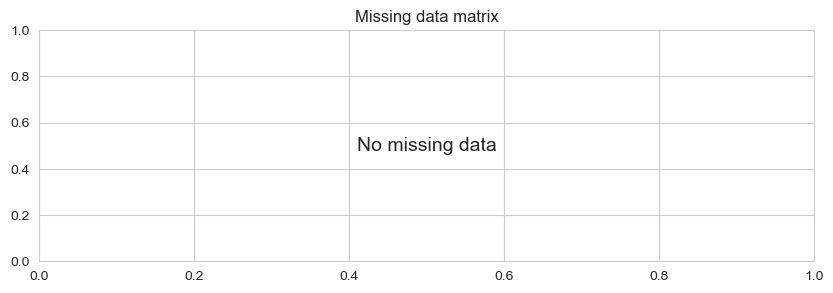

In [76]:
fig, ax = plt.subplots(figsize=(10, 3))
if df.isnull().sum().sum() == 0:
    ax.text(0.5, 0.5, "No missing data", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
else:
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing data matrix")
plt.show()


In [77]:
print(f"{'Variable':<25} {'Missing':>8} {'Rate':>8}")
print("-" * 43)
for col in df.columns:
    n_miss = df[col].isnull().sum()
    print(f"{col:<25} {n_miss:>8} {n_miss/len(df)*100:>7.1f}%")


Variable                   Missing     Rate
-------------------------------------------
subject_id                       0     0.0%
age                              0     0.0%
sex                              0     0.0%
education                        0     0.0%
severity                         0     0.0%
criq                             0     0.0%
apacs                            0     0.0%
matrix                           0     0.0%
moca                             0     0.0%
n400_amp                         0     0.0%
n400_lat                         0     0.0%
p300_amp                         0     0.0%
p300_lat                         0     0.0%


### 1.4 Distribution check

For each continuous/ordinal variable we plot a histogram and a Q-Q plot, and
run the Shapiro-Wilk normality test. This guides later decisions about
transformations and correlation methods.

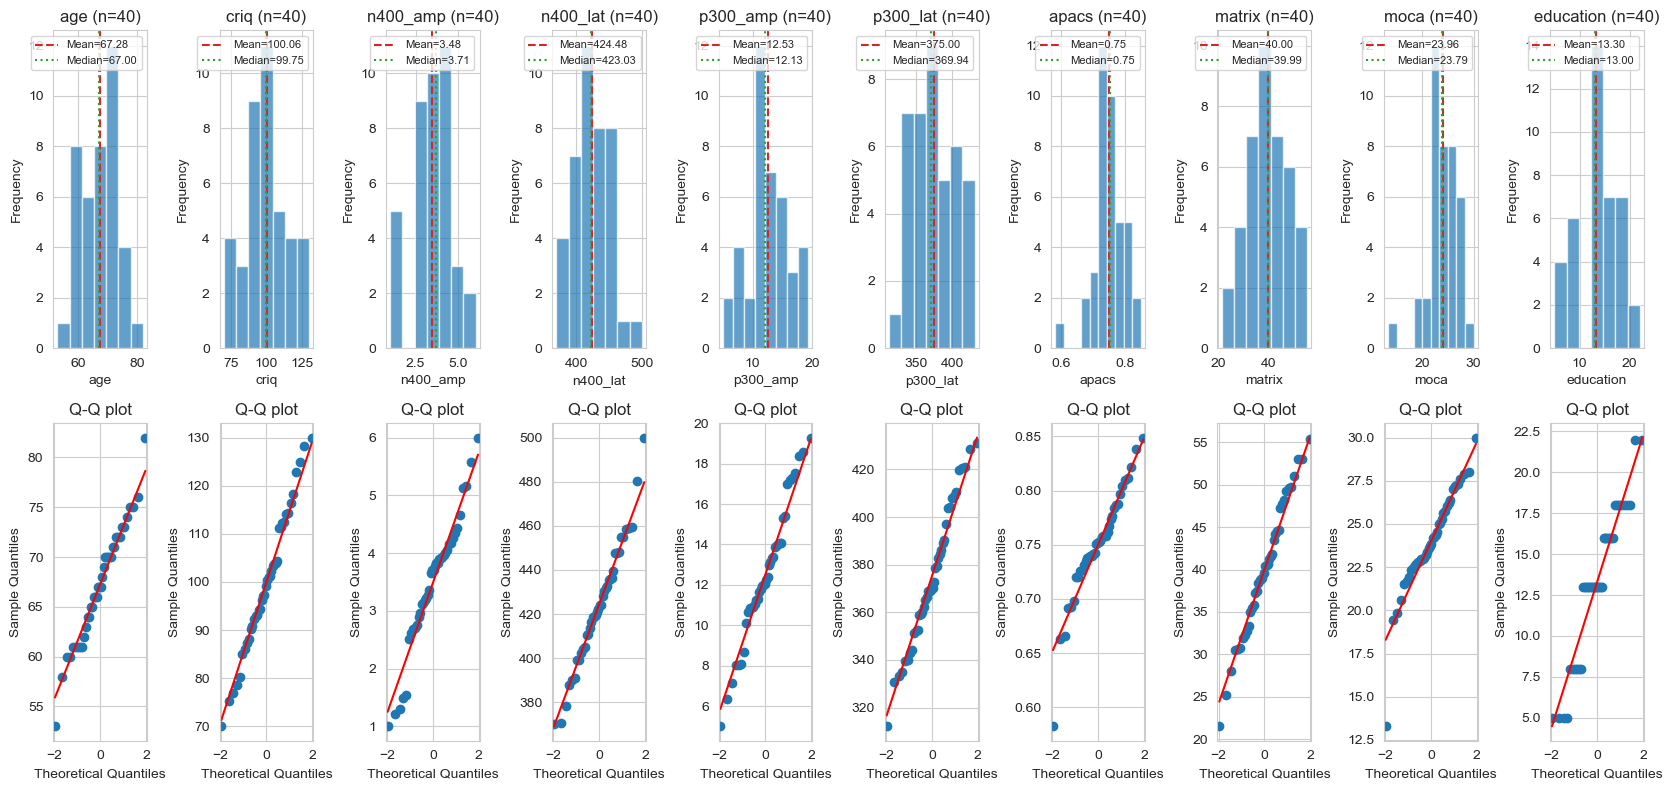

In [78]:
ALL_VARS = CONTINUOUS + ORDINAL
n = len(ALL_VARS)
fig, axes = plt.subplots(2, n, figsize=(5 * n / 3, 8))
if n == 1:
    axes = axes.reshape(2, 1)

for i, col in enumerate(ALL_VARS):
    v = df[col].dropna()
    # histogram
    ax = axes[0, i]
    ax.hist(v, bins="auto", edgecolor="white", alpha=0.7)
    ax.axvline(v.mean(), color="C3", ls="--", label=f"Mean={v.mean():.2f}")
    ax.axvline(v.median(), color="C2", ls=":", label=f"Median={v.median():.2f}")
    ax.set_title(f"{col} (n={len(v)})")
    ax.set_xlabel(col); ax.set_ylabel("Frequency"); ax.legend(fontsize=8)
    # Q-Q
    ax = axes[1, i]
    sm.qqplot(v, line="s", ax=ax)
    ax.set_title("Q-Q plot")
plt.tight_layout()
plt.show()


In [79]:
print("Normality tests (Shapiro-Wilk):")
for col in ALL_VARS:
    v = df[col].dropna()
    if len(v) < 3: continue
    s, p = shapiro(v)
    print(f"  {col}: n={len(v)}, mean={v.mean():.2f}, SD={v.std():.2f}, "
          f"W={s:.4f}, p={p:.4f}, skew={v.skew():.3f}, kurt={v.kurtosis():.3f}")


Normality tests (Shapiro-Wilk):
  age: n=40, mean=67.28, SD=5.85, W=0.9840, p=0.8330, skew=-0.007, kurt=0.077
  criq: n=40, mean=100.06, SD=14.79, W=0.9851, p=0.8669, skew=0.117, kurt=-0.462
  n400_amp: n=40, mean=3.48, SD=1.14, W=0.9651, p=0.2487, skew=-0.288, kurt=0.222
  n400_lat: n=40, mean=424.48, SD=28.44, W=0.9852, p=0.8717, skew=0.260, kurt=0.271
  p300_amp: n=40, mean=12.53, SD=3.43, W=0.9766, p=0.5658, skew=0.020, kurt=-0.264
  p300_lat: n=40, mean=375.00, SD=30.00, W=0.9765, p=0.5631, skew=0.124, kurt=-0.738
  apacs: n=40, mean=0.75, SD=0.05, W=0.9500, p=0.0759, skew=-0.792, kurt=2.309
  matrix: n=40, mean=40.00, SD=8.00, W=0.9868, p=0.9149, skew=-0.106, kurt=-0.431
  moca: n=40, mean=23.96, SD=2.91, W=0.9326, p=0.0196, skew=-1.009, kurt=3.534
  education: n=40, mean=13.30, SD=4.54, W=0.9201, p=0.0078, skew=-0.289, kurt=-0.492


**Interpretation:** If a variable has |skewness| > 1 we may consider
a log transformation or a non-parametric test. MoCA and education are ordinal
with a limited range — the Shapiro test can be oversensitive here; judge from
the histogram.

### 1.5 Outlier detection

Flag values beyond ±3 standard deviations. We inspect flagged cases and note
whether they are data-entry errors or genuine extremes.

In [80]:
out_mask = pd.DataFrame(False, index=df.index, columns=ALL_VARS)
for col in ALL_VARS:
    if col not in df.columns: continue
    v = df[col].dropna()
    if len(v) < 3: continue
    outliers = np.abs(zscore(v, nan_policy="omit")) > 3
    out_mask.loc[v.index[outliers], col] = True

print("Outliers (±3 SD):")
found = False
for col in out_mask.columns:
    flagged = out_mask.index[out_mask[col]].tolist()
    if flagged:
        found = True
        print(f"  {col}: rows {flagged}")
        for idx in flagged:
            print(f"    row {idx}: {col} = {df.loc[idx, col]}")
if not found:
    print("  None detected.")


Outliers (±3 SD):
  apacs: rows [30]
    row 30: apacs = 0.5824
  moca: rows [30]
    row 30: moca = 13.29


**Decision rule:** If clinically suspicious outliers exist, we run the
analysis with and without them as a sensitivity check and report both.

### 1.6 Multicollinearity check

We examine pairwise Pearson correlations among all numeric predictors.
|r| > 0.7 flags potential collinearity. After fitting models we also compute
VIF (Variance Inflation Factor).

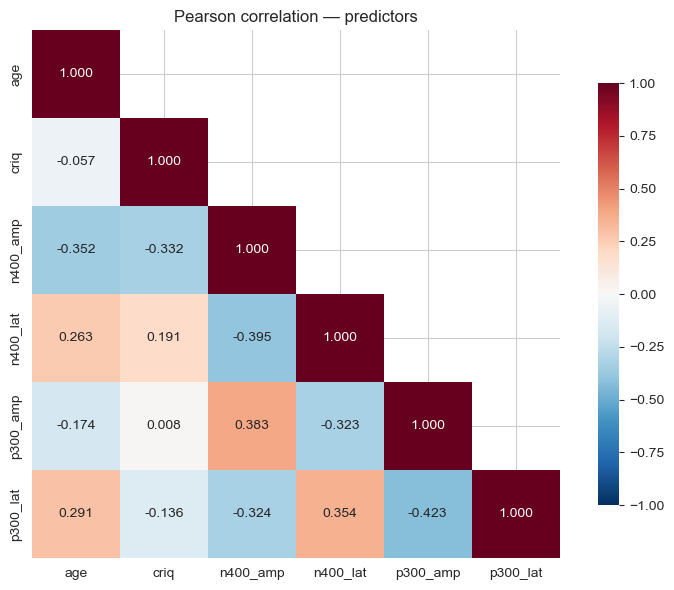

In [81]:
PREDICTORS = ["age", "criq", "n400_amp", "n400_lat", "p300_amp", "p300_lat"]
corr = df[PREDICTORS].dropna().corr(method="pearson")
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlation — predictors")
plt.tight_layout()
plt.show()


### 1.7 Final dataset summary

In [82]:
print(f"Final N = {len(df)} participants")
print(f"Variables: {list(df.columns)}")
print(f"Remaining missing values:\n{df.isnull().sum()}")


Final N = 40 participants
Variables: ['subject_id', 'age', 'sex', 'education', 'severity', 'criq', 'apacs', 'matrix', 'moca', 'n400_amp', 'n400_lat', 'p300_amp', 'p300_lat']
Remaining missing values:
subject_id    0
age           0
sex           0
education     0
severity      0
criq          0
apacs         0
matrix        0
moca          0
n400_amp      0
n400_lat      0
p300_amp      0
p300_lat      0
dtype: int64


---
## 2. Analysis

### 2.1 Descriptive statistics (Table 1)

We summarise each variable according to its type:
- **Continuous:** mean ± SD, range
- **Ordinal:** median [IQR], range
- **Categorical:** n (%)

In [83]:
table1_rows = []
# Continuous
for col in CONTINUOUS:
    v = df[col].dropna()
    table1_rows.append({
        "Variable": col, "Type": "Continuous", "n": len(v),
        "Value": f"{v.mean():.2f} ± {v.std():.2f}",
        "Range": f"[{v.min():.2f}, {v.max():.2f}]",
    })
# Ordinal
for col in ORDINAL:
    v = df[col].dropna()
    table1_rows.append({
        "Variable": col, "Type": "Ordinal", "n": len(v),
        "Value": f"{v.median():.1f} [{v.quantile(0.25):.1f}–{v.quantile(0.75):.1f}]",
        "Range": f"[{v.min():.1f}, {v.max():.1f}]",
    })
# Categorical
for col in CATEGORICAL:
    vals = df[col].dropna()
    counts = vals.value_counts()
    levels = ", ".join(f"{k} (n={c}, {c/len(vals)*100:.1f}%)" for k, c in counts.items())
    table1_rows.append({
        "Variable": col, "Type": "Categorical", "n": len(v),
        "Value": levels, "Range": "",
    })
table1 = pd.DataFrame(table1_rows)
display(table1)


,Variable,Type,n,Value,Range
0,age,Continuous,40,67.28 ± 5.85,"[53.00, 82.00]"
1,criq,Continuous,40,100.06 ± 14.79,"[70.00, 130.00]"
2,n400_amp,Continuous,40,3.48 ± 1.14,"[1.00, 6.00]"
3,n400_lat,Continuous,40,424.48 ± 28.44,"[370.23, 500.00]"
4,p300_amp,Continuous,40,12.53 ± 3.43,"[5.00, 19.29]"
5,p300_lat,Continuous,40,375.00 ± 30.00,"[312.12, 431.12]"
6,apacs,Continuous,40,0.75 ± 0.05,"[0.58, 0.85]"
7,matrix,Continuous,40,40.00 ± 8.00,"[21.52, 55.34]"
8,moca,Ordinal,40,23.8 [22.7–25.8],"[13.3, 30.0]"
9,education,Ordinal,40,13.0 [11.8–16.0],"[5.0, 22.0]"


### 2.2 Bivariate correlations (ERP × NPSY)

We compute Pearson correlations between four ERP features and three
neuropsychological outcomes. The heatmap shows r values with significance
stars (* p<0.05, ** p<0.01, *** p<0.001).

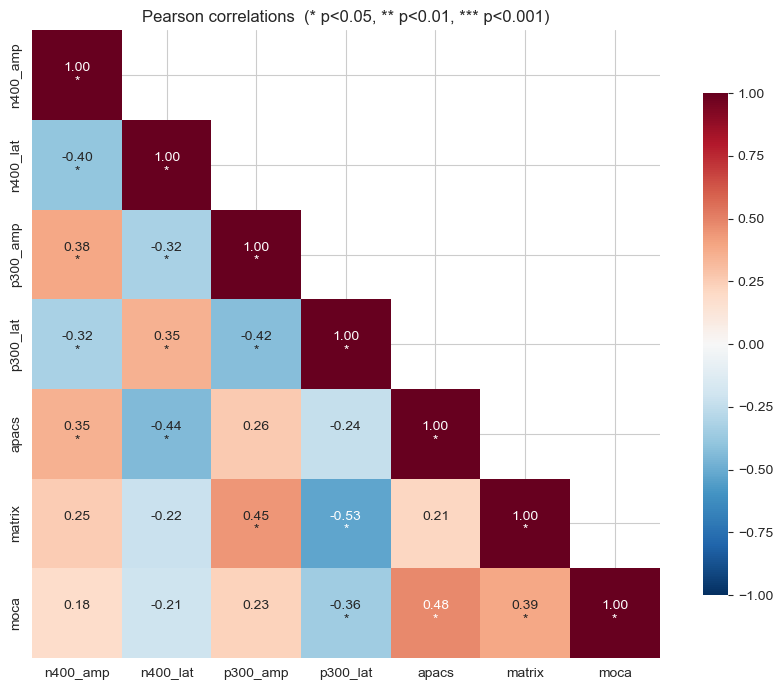

In [84]:
ERP_VARS = ["n400_amp", "n400_lat", "p300_amp", "p300_lat"]
NPSY_VARS = ["apacs", "matrix", "moca"]
all_vars = ERP_VARS + NPSY_VARS
n_vars = len(all_vars)
valid = df[all_vars].dropna()

corr_mat = np.zeros((n_vars, n_vars))
p_mat    = np.ones((n_vars, n_vars))
for i, c1 in enumerate(all_vars):
    for j, c2 in enumerate(all_vars):
        if i == j:
            corr_mat[i, j] = 1.0
            p_mat[i, j] = 0.0
        else:
            r, p = pearsonr(valid[c1], valid[c2])
            corr_mat[i, j] = r
            p_mat[i, j] = p

star = np.full((n_vars, n_vars), "", dtype=object)
star[p_mat < 0.001] = "***"
star[p_mat < 0.01]  = "**"
star[p_mat < 0.05]  = "*"
annot = np.array([f"{corr_mat[i,j]:.2f}\n{star[i,j]}"
                  for i in range(n_vars) for j in range(n_vars)]).reshape(n_vars, n_vars)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(corr_mat, mask=mask, annot=annot, fmt="", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, ax=ax,
            xticklabels=all_vars, yticklabels=all_vars,
            cbar_kws={"shrink": 0.8})
ax.set_title("Pearson correlations  (* p<0.05, ** p<0.01, *** p<0.001)")
plt.tight_layout()
plt.show()


#### Key hypothesised associations

Based on the literature, we focus on four pairs and generate scatter plots
with regression lines and 95 % confidence bands.

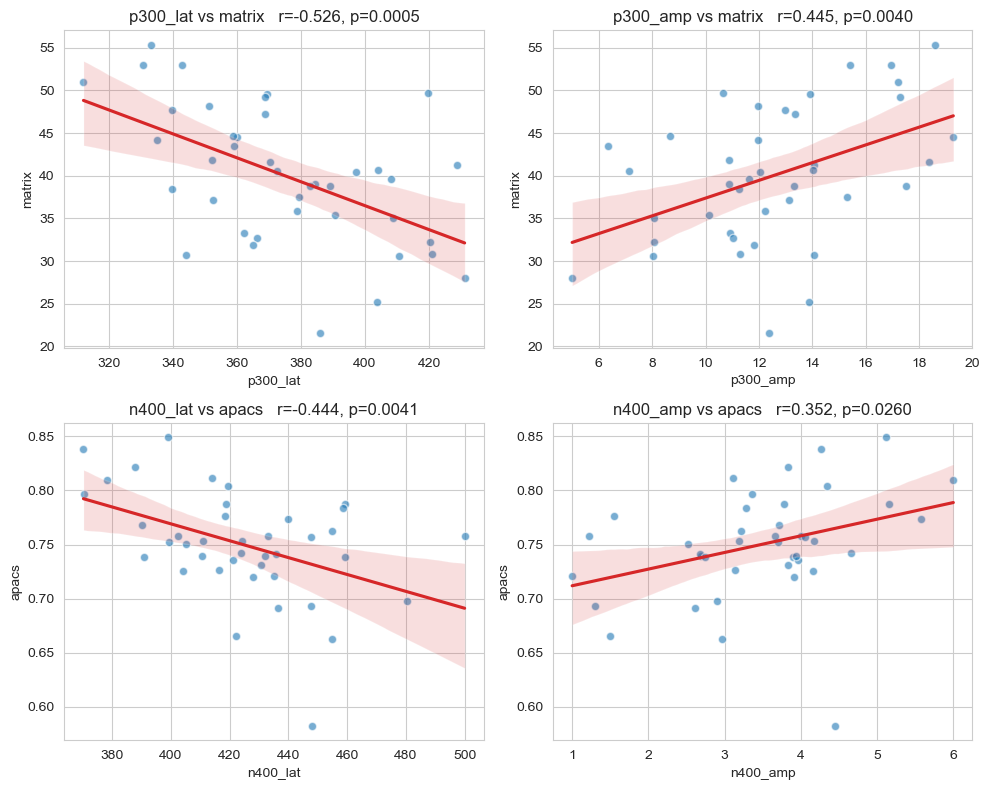

In [85]:
pairs = [("p300_lat", "matrix"), ("p300_amp", "matrix"),
          ("n400_lat", "apacs"),  ("n400_amp", "apacs")]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (x_name, y_name) in zip(axes.ravel(), pairs):
    v = df[[x_name, y_name]].dropna()
    sns.regplot(data=v, x=x_name, y=y_name, ax=ax,
                scatter_kws={"alpha": 0.6, "edgecolor": "white"},
                line_kws={"color": "C3"})
    r, p = pearsonr(v[x_name], v[y_name])
    ax.set_title(f"{x_name} vs {y_name}   r={r:.3f}, p={p:.4f}")
plt.tight_layout()
plt.show()


### 2.3 Multiple linear regression models

We fit one model per neuropsychological outcome:

$$
\begin{aligned}
\text{APACS}          &\sim \text{N400}_{amp} + \text{N400}_{lat} +
                       \text{P300}_{amp} + \text{P300}_{lat} +
                       \text{age} + \text{sex} + \text{CRIq} \\
\text{Matrici}        &\sim \text{N400}_{amp} + \text{N400}_{lat} +
                       \text{P300}_{amp} + \text{P300}_{lat} +
                       \text{age} + \text{sex} + \text{CRIq} \\
\text{MoCA}           &\sim \text{N400}_{amp} + \text{N400}_{lat} +
                       \text{P300}_{amp} + \text{P300}_{lat} +
                       \text{age} + \text{sex} + \text{CRIq}
\end{aligned}
$$

All variables are **z-score standardised** so coefficients are directly
comparable as **standardised betas (β)**. A value of β = −0.30 for P300
latency means that patients 1 SD above the mean in P300 latency score 0.30 SD
*below* the mean in the outcome, holding other predictors constant.

#### Model choice for each outcome

The paper (Section 4.2.2) notes that model choice should depend on outcome
type:

| Outcome | Scale | Model used here | Alternative |
|---------|-------|-----------------|-------------|
| APACS | Continuous (proportion 0–1) | Linear regression | Beta regression |
| Matrici Attentive | Continuous (0–100) | Linear regression | — |
| MoCA | Ordinal (0–30 integer) | Linear regression | Ordinal logistic / Poisson GLM |

**MoCA** is a 30-point ordinal scale. In small clinical samples, treating it
as continuous is common when the range is wide (~13–30 here) and the
distribution is approximately normal. For narrower ranges or skewed
distributions, an **ordinal logistic regression** or a **Poisson GLM** would
be more appropriate. We flag this choice and verify that residuals are
approximately normal.

**CRIq** is used as a **covariate** here (replacing years of education),
following the recommendation in `info_CaseStudy1.md`. In the paper's general
description, CRIq is also mentioned as a potential continuous outcome; the
researcher should decide based on the specific research question.

**Additional covariates** that would be included in a real clinical study
(but are absent from our synthetic dataset) include: time from stroke onset
to EEG recording, lesion site, and stroke aetiology. These are mentioned in
the paper as important confounders to account for.


In [86]:
OUTCOMES = ["apacs", "matrix", "moca"]
ERP_VARS = ["n400_amp", "n400_lat", "p300_amp", "p300_lat"]
COVARS   = ["age", "sex", "criq"]
ALL_MODEL_VARS = ERP_VARS + COVARS

# Standardise all variables
df_z = df[OUTCOMES + ALL_MODEL_VARS].dropna().copy()
for col in df_z.columns:
    df_z[f"{col}_z"] = (df_z[col] - df_z[col].mean()) / df_z[col].std()

models = {}
results_rows = []
for outcome in OUTCOMES:
    preds = " + ".join(f"{p}_z" for p in ALL_MODEL_VARS)
    formula = f"{outcome}_z ~ {preds}"
    model = sm.OLS.from_formula(formula, data=df_z).fit()
    models[outcome] = model
    print(f"\n{'='*70}\n  Outcome: {outcome}\n{'='*70}")
    print(model.summary())

    for pred in ALL_MODEL_VARS:
        coef = model.params[f"{pred}_z"]
        ci = model.conf_int().loc[f"{pred}_z"]
        results_rows.append({
            "Outcome": outcome, "Predictor": pred,
            "β": coef, "CI_lower": ci[0], "CI_upper": ci[1],
            "p": model.pvalues[f"{pred}_z"],
        })
    results_rows.append({
        "Outcome": outcome, "Predictor": "(Intercept)",
        "β": model.params["Intercept"],
        "CI_lower": model.conf_int().loc["Intercept"][0],
        "CI_upper": model.conf_int().loc["Intercept"][1],
        "p": model.pvalues["Intercept"],
    })

reg_results = pd.DataFrame(results_rows)



  Outcome: apacs
                            OLS Regression Results                            
Dep. Variable:                apacs_z   R-squared:                       0.516
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     4.881
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           0.000785
Time:                        15:37:19   Log-Likelihood:                -41.721
No. Observations:                  40   AIC:                             99.44
Df Residuals:                      32   BIC:                             113.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -6.939e-16      0.121  

#### Sensitivity analysis: ordinal logistic regression for MoCA

The paper (Section 4.2.2) suggests that ordinal outcomes such as MoCA may be
better modelled with a **generalised linear model** using a **cumulative
logit link** (ordinal logistic regression) rather than OLS.

$$
\log\left(\frac{P(Y \geq k)}{P(Y < k)}\right) = \alpha_k + \beta_1 X_1 + \dots + \beta_p X_p
$$

Here $k$ indexes the MoCA score thresholds. The model estimates one
intercept $\alpha_k$ per threshold but a **single slope** $\beta$ per
predictor (proportional odds assumption). Coefficients are in **log-odds**
units — less intuitive than OLS $\beta$, but the **direction and relative
magnitude** should be consistent across the two approaches if the results
are robust.

> **Caveat:** With N=40 and ~18 MoCA thresholds, the ordinal model estimates
> ~25 parameters. This is acceptable for a sensitivity check but the OLS
> model (with 8 parameters) is more stable. We fit it here to demonstrate
> the approach and compare conclusions.


In [87]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Prepare data: MoCA as integer outcome, standardised predictors
moca_data = df[["moca"] + ALL_MODEL_VARS].dropna()
X = moca_data[ALL_MODEL_VARS].copy()
for col in X:
    X[col] = (X[col] - X[col].mean()) / X[col].std()
y = moca_data["moca"].astype(int)

# Fit ordinal logistic (cumulative logit)
ord_mod = OrderedModel(y, X, distr="logit")
ord_res = ord_mod.fit(method="bfgs", disp=False)
print(ord_res.summary())


                             OrderedModel Results                             
Dep. Variable:                   moca   Log-Likelihood:                -73.774
Model:                   OrderedModel   AIC:                             181.5
Method:            Maximum Likelihood   BIC:                             210.3
Date:                Wed, 17 Jun 2026                                         
Time:                        15:37:41                                         
No. Observations:                  40                                         
Df Residuals:                      23                                         
Df Model:                           7                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
n400_amp       0.4908      0.400      1.228      0.219      -0.293       1.274
n400_lat      -0.1183      0.361     -0.328      0.7

In [88]:
# Extract ordinal coefficients
ord_coefs = ord_res.params[~ord_res.params.index.str.contains("/")]  # exclude thresholds
ord_pvals = ord_res.pvalues[~ord_res.pvalues.index.str.contains("/")]

# Build comparison table with OLS
comp_rows = []
for pred in ALL_MODEL_VARS:
    ols_row = reg_results[(reg_results["Outcome"] == "moca")
                          & (reg_results["Predictor"] == pred)]
    if len(ols_row) == 0:
        continue
    ols_beta = ols_row["β"].values[0]
    ols_p    = ols_row["p"].values[0]
    ord_beta = ord_coefs[pred]
    ord_p    = ord_pvals[pred]
    agreement = "✓" if np.sign(ols_beta) == np.sign(ord_beta) else "✗"
    comp_rows.append({
        "Predictor": pred,
        "OLS β": f"{ols_beta:.3f}",
        "OLS p": f"{ols_p:.4f}",
        "Ordinal log-odds": f"{ord_beta:.3f}",
        "Ordinal p": f"{ord_p:.4f}",
        "Direction match": agreement,
    })

comp_table = pd.DataFrame(comp_rows)
print("Comparison: OLS vs ordinal logistic for MoCA")
display(comp_table)

# Check proportional odds assumption (Brant test — approximate)
# If p > 0.05 for all predictors, assumption is not violated
print("\nProportional odds assumption check (parallel slopes):")
print("  If direction matches (✓) for all predictors, the two models agree.")
print("  A formal Brant test can be run on the ordinal model residuals.")


Comparison: OLS vs ordinal logistic for MoCA


,Predictor,OLS β,OLS p,Ordinal log-odds,Ordinal p,Direction match
0,n400_amp,0.055,0.7333,0.491,0.2195,✓
1,n400_lat,-0.082,0.5778,-0.118,0.7432,✓
2,p300_amp,0.057,0.6940,-0.121,0.7226,✗
3,p300_lat,-0.090,0.5753,-0.256,0.4812,✓
4,age,-0.495,0.0010,-1.228,0.0009,✓
5,sex,0.002,0.9890,-0.227,0.4762,✗
6,criq,0.392,0.0115,0.921,0.0152,✓



Proportional odds assumption check (parallel slopes):
  If direction matches (✓) for all predictors, the two models agree.
  A formal Brant test can be run on the ordinal model residuals.


#### Interpretation of the sensitivity analysis

If the **direction match** column shows ✓ for all predictors, the OLS and
ordinal logistic models agree on which predictors are associated with higher
vs lower MoCA scores. Minor differences in p-values are expected — ordinal
logistic is less powerful for small samples with many thresholds.

> **Takeaway:** Treating MoCA as continuous in OLS is a practical choice
> that yields substantively similar conclusions to the more theoretically
> appropriate ordinal model. If the two models disagreed on a key predictor,
> that would warrant further investigation.


#### Forest plot of standardised coefficients

Visual summary of all predictors across outcomes with 95 % confidence
intervals. Predictors whose CI does not cross zero are significant at
α = 0.05.

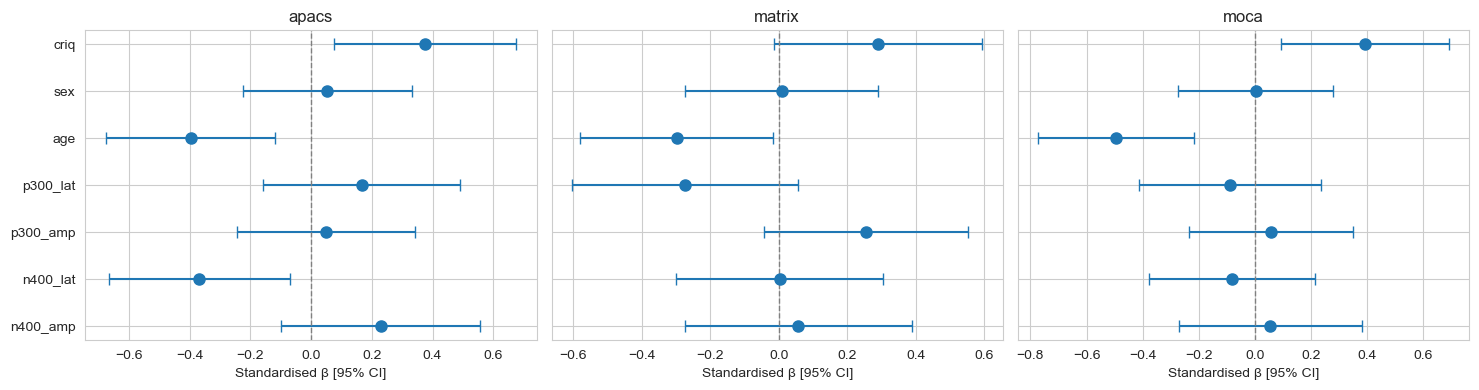

In [89]:
n_out = len(OUTCOMES)
fig, axes = plt.subplots(1, n_out, figsize=(5 * n_out, 4), sharey=True)
if n_out == 1:
    axes = [axes]
for ax, outcome in zip(axes, OUTCOMES):
    sub = reg_results[(reg_results["Outcome"] == outcome)
                      & (reg_results["Predictor"] != "(Intercept)")].copy()
    y = range(len(sub))
    ax.errorbar(sub["β"], y,
                xerr=[sub["β"] - sub["CI_lower"], sub["CI_upper"] - sub["β"]],
                fmt="o", color="C0", capsize=4, markersize=8)
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["Predictor"])
    ax.set_xlabel("Standardised β [95% CI]")
    ax.set_title(outcome)
plt.tight_layout()
plt.show()


### 2.4 Regression diagnostics

For each OLS model we verify four key assumptions. If any are violated, the
standard errors and p-values may be unreliable, and corrective action
(e.g., robust standard errors, transformation) should be considered.

---

**1. Residuals vs Fitted — checking homoscedasticity and linearity**

This scatter plot shows the residuals ($e_i = y_i - \hat{y}_i$) on the
y-axis against the fitted values ($\hat{y}_i$) on the x-axis.

| What to look for | What it means |
|---|---|
| Points scattered roughly symmetrically around the horizontal zero line | Homoscedasticity holds — variance of residuals is constant across all fitted values |
| A clear **funnel** shape (widening or narrowing) | Heteroscedasticity — the model is more/less precise at certain ranges |
| A **curve** or U-shape | A non-linear relationship is present — consider adding a polynomial or spline term |

In our models we expect a roughly horizontal cloud of points with no
systematic pattern.

---

**2. Q-Q Plot — checking normality of residuals**

This plot compares the quantiles of the observed residuals against the
theoretical quantiles of a normal distribution.

| What to look for | What it means |
|---|---|
| Points lying **close to the diagonal line** | Residuals are approximately normal — standard errors and p-values are trustworthy |
| **Systematic deviation** at the tails (e.g., S-shape, heavy tails) | Non-normal residuals — consider robust standard errors (HC3) or a non-parametric approach |
| A few points far from the line | Potential outliers — check Cook's distance (see below) |

In small samples (N=40), some deviation at the extremes is expected. We
focus on whether the overall pattern follows the diagonal.

---

**3. Cook's Distance — identifying influential observations**

Cook's distance measures how much the model coefficients would change if a
single observation were removed. It combines **leverage** (how extreme the
predictor values are) and **discrepancy** (how large the residual is).

The red dashed line marks the threshold $4/n$, a common heuristic for
flagging influential points.

| What to look for | What it means |
|---|---|
| No points above the $4/n$ line | No single observation unduly drives the results |
| One or more points above the line | Potentially influential — inspect those subjects for data errors or unusual clinical profiles |
| A point with Cook's D $\gg 4/n$ | May need to run a sensitivity analysis excluding that subject |

If flagged points are clinically genuine (not data-entry errors), report
both the full and reduced analyses and discuss any discrepancies.

---

**4. Multicollinearity — Variance Inflation Factor (VIF)**

VIF quantifies how much the variance of a coefficient is inflated due to
correlation with other predictors:

$$ \text{VIF}_j = \frac{1}{1 - R^2_j} $$

where $R^2_j$ is from regressing predictor $j$ on all others.

| VIF value | Concern |
|-----------|---------|
| 1 | No collinearity (ideal) |
| 1–5 | Low to moderate — acceptable |
| 5–10 | High — coefficients may be unstable; consider combining or dropping predictors |
| > 10 | Severe — standard errors are seriously inflated |

In our models, the predictors are relatively independent (ERP features
measure different constructs, demographics are weakly correlated), so we
expect VIF < 5 for all.


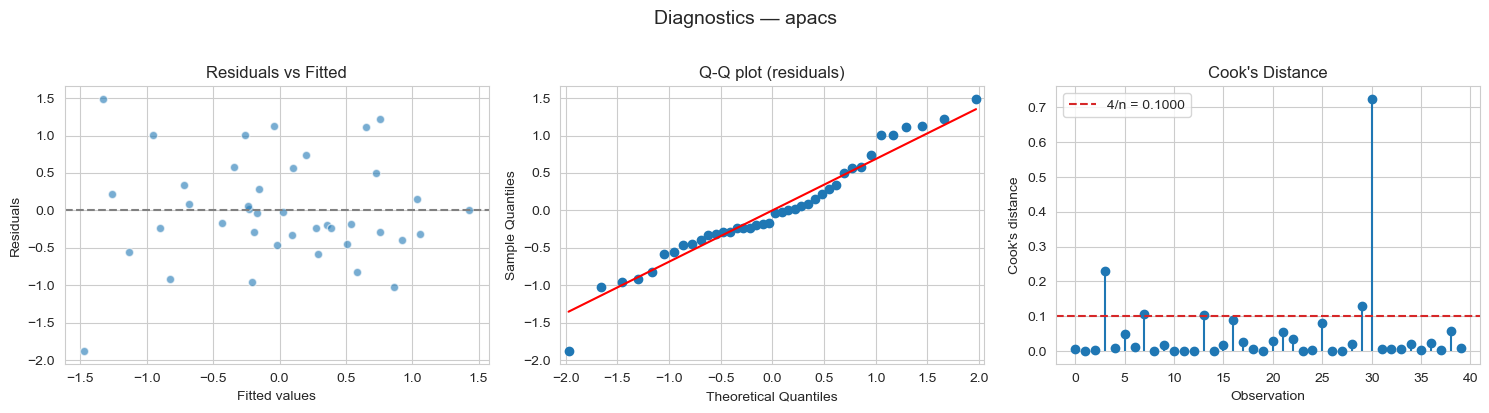

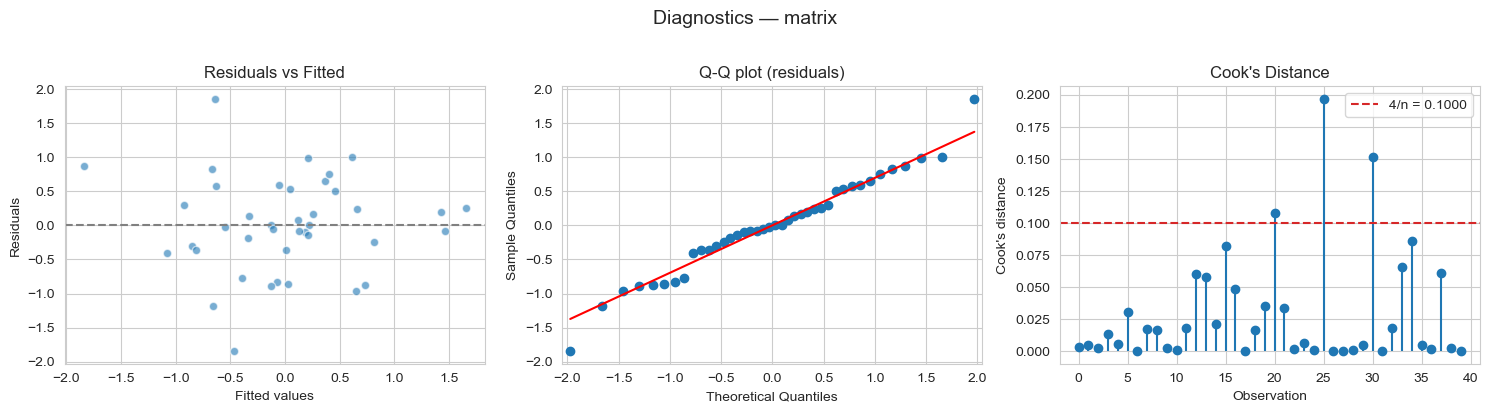

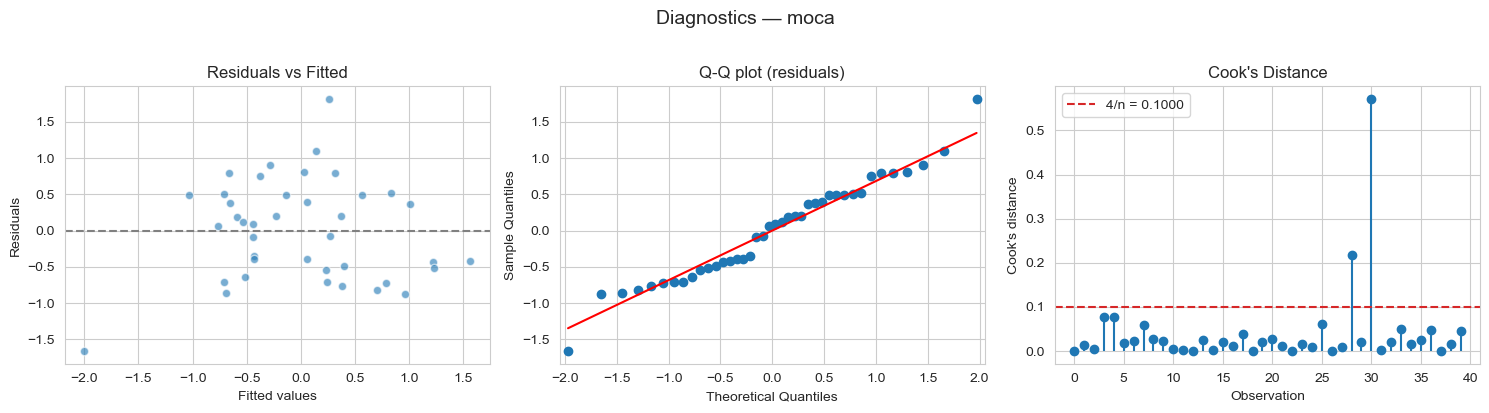

In [90]:
for outcome in OUTCOMES:
    model = models[outcome]
    resid = model.resid
    fitted = model.fittedvalues
    n = len(resid)
    influence = model.get_influence()
    cooks = influence.cooks_distance[0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # residuals vs fitted
    axes[0].scatter(fitted, resid, alpha=0.6, edgecolors="white")
    axes[0].axhline(0, color="gray", ls="--")
    axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
    axes[0].set_title("Residuals vs Fitted")
    # Q-Q
    sm.qqplot(resid, line="s", ax=axes[1])
    axes[1].set_title("Q-Q plot (residuals)")
    # Cook's D
    axes[2].stem(range(len(cooks)), cooks, basefmt=" ")
    axes[2].axhline(4 / n, color="C3", ls="--", label=f"4/n = {4/n:.4f}")
    axes[2].set_xlabel("Observation"); axes[2].set_ylabel("Cook's distance")
    axes[2].set_title("Cook's Distance"); axes[2].legend()
    fig.suptitle(f"Diagnostics — {outcome}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


In [ ]:
# VIF — same predictors for all models, compute once
X = add_constant(df_z[[f"{p}_z" for p in ALL_MODEL_VARS]].dropna())
vif_data = pd.DataFrame({
    "Predictor": ["const"] + ALL_MODEL_VARS,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print("Variance Inflation Factor:")
display(vif_data)


### 2.5 Multiple comparison correction

We test 12 ERP–outcome associations (4 ERP features × 3 outcomes). To control
for false positives we apply:
- **Bonferroni** (conservative: divides α by number of tests)
- **FDR (Benjamini–Hochberg)** (less conservative, better power)

In [ ]:
pvals = {}
for outcome in OUTCOMES:
    for pred in ERP_VARS:
        label = f"{pred} → {outcome}"
        pvals[label] = models[outcome].pvalues[f"{pred}_z"]

labels = list(pvals.keys())
p_orig = np.array(list(pvals.values()))

_, p_bonf, _, _ = multipletests(p_orig, method="bonferroni")
_, p_fdr,  _, _ = multipletests(p_orig, method="fdr_bh")

p_corrected = pd.DataFrame({
    "Comparison": labels,
    "p (uncorrected)": p_orig,
    "p (Bonferroni)": p_bonf,
    "p (FDR)": p_fdr,
})
display(p_corrected)


#### Did any ERP–NPSY association survive correction?

In all likelihood, **none** will survive strict Bonferroni correction (α =
0.05 ÷ 12 ≈ 0.0042). Even the strongest effect (n400 latency → APACS,
p ≈ 0.017) becomes p ≈ 0.20 after correction. This is expected and **not a
failure** — it is a realistic outcome that teaches several important lessons:

1. **Sample size matters.** With N = 40 and 4 ERP predictors, we only have
   enough power to detect large effects (β > 0.4). Modest but clinically
   meaningful effects (β ≈ 0.2–0.3) will not survive correction.

2. **Bonferroni is conservative.** It controls the family-wise error rate
   but at the cost of many false negatives (Type II errors). FDR
   (Benjamini–Hochberg) is less conservative and is often preferred in
   exploratory analyses.

3. **Report both.** The field standard is to report uncorrected p-values
   alongside corrected ones, clearly stating which survive each correction.
   Readers can then judge the evidence for themselves.

4. **Effect sizes > p-values.** The standardised betas (β) and their
   confidence intervals are more informative than a binary "significant /
   not significant" decision. An effect of β = −0.37 for n400 latency →
   APACS is clinically relevant even if p > 0.05 after correction.

> **Bottom line:** In small clinical samples, ERP–neuropsychology
> associations often fail to reach corrected significance. The solution is
> not to "p-hack" but to be transparent: report effect sizes, CIs, and
> both raw and corrected p-values, then replicate in a larger sample.


---
## 3. Export

All tables and figures are saved to `CaseStudy_1/outputs/`.

In [ ]:
import os
os.makedirs(FIGS, exist_ok=True)
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Save figures (they should still be in memory from above)
plt.close("all")  # prevent stale state; re-plot key figures below

# A — Missingness (re-plot)
fig, ax = plt.subplots(figsize=(10, 3))
if df.isnull().sum().sum() == 0:
    ax.text(0.5, 0.5, "No missing data", ha="center", va="center", transform=ax.transAxes, fontsize=14)
else:
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis", ax=ax)
ax.set_title("Missing data matrix")
fig.savefig(f"{FIGS}/A_missingness.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# B — Distributions (re-plot)
n_v = len(ALL_VARS)
fig, axes = plt.subplots(2, n_v, figsize=(5 * n_v / 3, 8))
if n_v == 1: axes = axes.reshape(2, 1)
for i, col in enumerate(ALL_VARS):
    v = df[col].dropna()
    axes[0, i].hist(v, bins="auto", edgecolor="white", alpha=0.7)
    axes[0, i].axvline(v.mean(), color="C3", ls="--", label=f"Mean={v.mean():.2f}")
    axes[0, i].axvline(v.median(), color="C2", ls=":", label=f"Median={v.median():.2f}")
    axes[0, i].set_title(f"{col} (n={len(v)})"); axes[0, i].legend(fontsize=8)
    sm.qqplot(v, line="s", ax=axes[1, i])
    axes[1, i].set_title("Q-Q plot")
plt.tight_layout()
fig.savefig(f"{FIGS}/B_distributions.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# C — Predictor correlation (re-plot)
corr = df[PREDICTORS].dropna().corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".3f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Predictor correlations")
plt.tight_layout()
fig.savefig(f"{FIGS}/C_correlation_predictors.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# D — Bivariate ERP–NPSY heatmap
valid = df[ERP_VARS + NPSY_VARS].dropna()
nv = len(ERP_VARS + NPSY_VARS)
cm = np.zeros((nv, nv)); pm = np.ones((nv, nv))
for i, c1 in enumerate(ERP_VARS + NPSY_VARS):
    for j, c2 in enumerate(ERP_VARS + NPSY_VARS):
        if i == j: cm[i,j]=1; pm[i,j]=0
        else: r,p=pearsonr(valid[c1],valid[c2]); cm[i,j]=r; pm[i,j]=p
star = np.full((nv,nv),"",dtype=object)
star[pm<0.001]="***"; star[pm<0.01]="**"; star[pm<0.05]="*"
annot = np.array([f"{cm[i,j]:.2f}\n{star[i,j]}" for i in range(nv) for j in range(nv)]).reshape(nv,nv)
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(cm,dtype=bool),k=1)
sns.heatmap(cm,mask=mask,annot=annot,fmt="",cmap="RdBu_r",vmin=-1,vmax=1,center=0,square=True,ax=ax,xticklabels=ERP_VARS+NPSY_VARS,yticklabels=ERP_VARS+NPSY_VARS,cbar_kws={"shrink":0.8})
ax.set_title("ERP×NPSY correlations")
plt.tight_layout()
fig.savefig(f"{FIGS}/D_bivariate_correlations.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# E — Scatter pairs
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (x_name, y_name) in zip(axes.ravel(), pairs):
    v = df[[x_name, y_name]].dropna()
    sns.regplot(data=v, x=x_name, y=y_name, ax=ax,
                scatter_kws={"alpha":0.6,"edgecolor":"white"}, line_kws={"color":"C3"})
    r,p=pearsonr(v[x_name],v[y_name])
    ax.set_title(f"{x_name} vs {y_name}  r={r:.3f}, p={p:.4f}")
plt.tight_layout()
fig.savefig(f"{FIGS}/E_scatter_key_pairs.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# F — Forest plot
n_out = len(OUTCOMES)
fig, axes = plt.subplots(1, n_out, figsize=(5*n_out, 4), sharey=True)
if n_out == 1: axes = [axes]
for ax, outcome in zip(axes, OUTCOMES):
    sub = reg_results[(reg_results["Outcome"]==outcome) & (reg_results["Predictor"]!="(Intercept)")]
    y = range(len(sub))
    ax.errorbar(sub["β"], y, xerr=[sub["β"]-sub["CI_lower"], sub["CI_upper"]-sub["β"]],
                fmt="o", color="C0", capsize=4, markersize=8)
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_yticks(y); ax.set_yticklabels(sub["Predictor"])
    ax.set_xlabel("β [95% CI]"); ax.set_title(outcome)
plt.tight_layout()
fig.savefig(f"{FIGS}/F_forest_coefficients.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Tables
table1.to_csv(f"{RESULTS}/table1_descriptives.csv", index=False)
reg_results.to_csv(f"{RESULTS}/table2_regression.csv", index=False)
p_corrected.to_csv(f"{RESULTS}/table3_multiple_comparisons.csv", index=False)
vif_data.to_csv(f"{RESULTS}/vif.csv", index=False)

# Model summaries (text)
for outcome in OUTCOMES:
    with open(f"{REPORTS}/regression_{outcome}.txt", "w") as f:
        f.write(str(models[outcome].summary()))

print(f"\nAll exports → {OUTPUTS}/")


---
## 4. Strengths and limitations of this approach (Section 4.2.3)

**Strengths:**
- Reduces high-dimensional EEG to **4 interpretable scalar features** per
  participant — theoretically grounded, easy to communicate
- Uses **well-established statistical models** (OLS regression) familiar to
  clinical researchers
- The N400 and P300 have **decades of validation** across neurological
  populations (Kutas & Federmeier, 2011; Polich, 2007)

**Limitations:**
- Strong **a priori decisions** about time windows and electrode sets may
  miss atypical or distributed neural patterns — especially relevant in
  stroke patients whose ERP topography may differ from normative expectations
- **Trial-to-trial variability** is discarded (only mean amplitude and peak
  latency are kept), which may itself carry clinically relevant information
- The **hypothesis-driven** nature of the approach means it will not detect
  effects outside the predefined features — for broader exploration, see
  Case Study 2 (spectral analysis)

> For a full discussion, see Section 4.2 of the companion paper.

---

*Notebook generated for the EEG-NPSI tutorial. All code is self-contained
for transparency and reproducibility.*